In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import cos, sin

# Загрузим изображения для основных заданий и для обработки линий

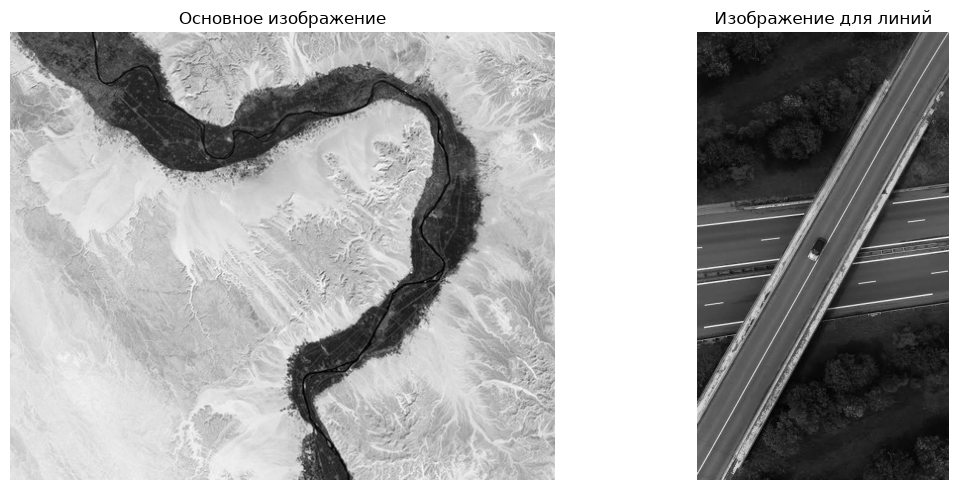

In [45]:
IMG_MAIN  = "nil.jpg"
IMG_LINES = "road.jpg"

src_main = cv2.imread(IMG_MAIN)
if src_main is None:
    raise FileNotFoundError(f"Не найден файл {IMG_MAIN}")

src_lines = cv2.imread(IMG_LINES)
if src_lines is None:
    raise FileNotFoundError(f"Не найден файл {IMG_LINES}")

gray_main  = cv2.cvtColor(src_main,  cv2.COLOR_BGR2GRAY)
gray_lines = cv2.cvtColor(src_lines, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray_main, cmap="gray")
plt.title("Основное изображение")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_lines, cmap="gray")
plt.title("Изображение для линий")
plt.axis("off")
plt.tight_layout()
plt.show()


# Бинаризация с фикс. порогами

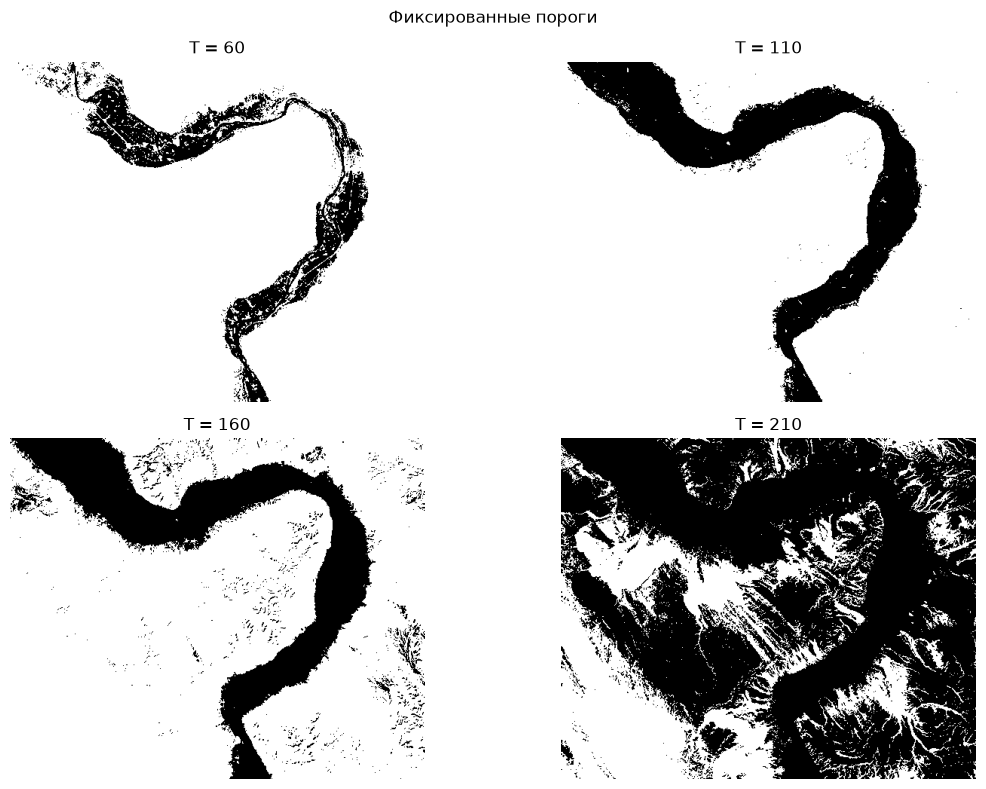

In [46]:
def fixed_binarize(img, level):
    """Возвращает ч/б изображение по фиксированному порогу."""
    return (img >= level).astype(np.uint8) * 255


levels = (60, 110, 160, 210)
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for axis, lvl in zip(ax.ravel(), levels):
    axis.imshow(fixed_binarize(gray_main, lvl), cmap="gray")
    axis.set_title(f"T = {lvl}")
    axis.axis("off")
fig.suptitle("Фиксированные пороги")
plt.tight_layout()
plt.show()

# Метод Оцу

Otsu. Подобранный порог = 131.0


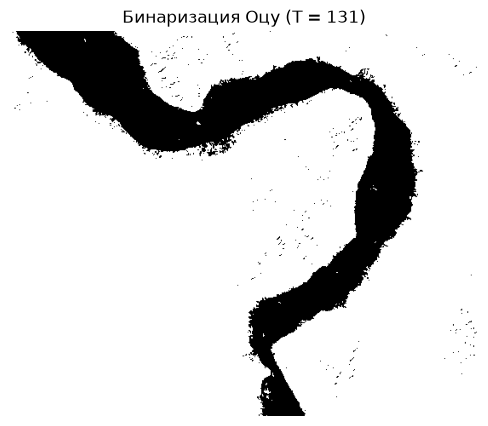

In [47]:
otsu_val, otsu_bin = cv2.threshold(
    gray_main, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU
)
print(f"Otsu. Подобранный порог = {otsu_val:.1f}")

plt.figure(figsize=(7, 5))
plt.imshow(otsu_bin, cmap="gray")
plt.title(f"Бинаризация Оцу (T = {otsu_val:.0f})")
plt.axis("off")
plt.show()

# Адаптивн. бинаризация

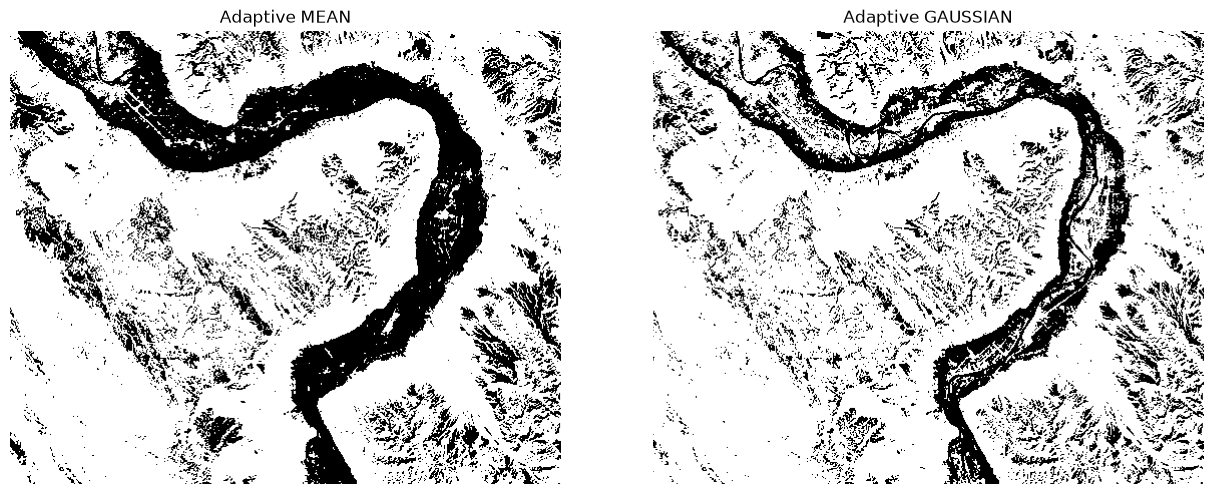

In [48]:
block = 65
const = 12

adapt_mean = cv2.adaptiveThreshold(
    gray_main, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY, block, const
)
adapt_gauss = cv2.adaptiveThreshold(
    gray_main, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, block, const
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(adapt_mean,  cmap="gray"); axes[0].set_title("Adaptive MEAN")
axes[1].imshow(adapt_gauss, cmap="gray"); axes[1].set_title("Adaptive GAUSSIAN")
for a in axes: a.axis("off")
plt.tight_layout()
plt.show()

# Оператор собеля

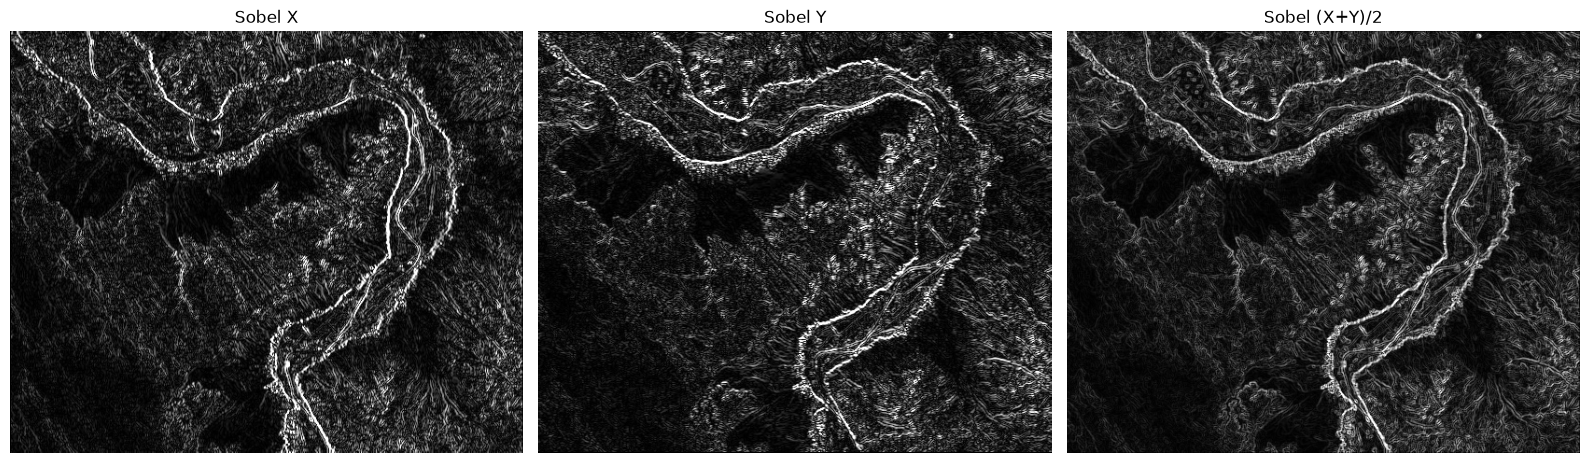

In [49]:
def sobel_norm(img, dx, dy, k=3):
    g = cv2.Sobel(img, cv2.CV_16S, dx, dy, ksize=k)
    return cv2.convertScaleAbs(g)


gx   = sobel_norm(gray_main, 1, 0)
gy   = sobel_norm(gray_main, 0, 1)
gsum = cv2.addWeighted(gx, 0.5, gy, 0.5, 0.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for a, im, t in zip(axes,
                    (gx, gy, gsum),
                    ("Sobel X", "Sobel Y", "Sobel (X+Y)/2")):
    a.imshow(im, cmap="gray")
    a.set_title(t)
    a.axis("off")
plt.tight_layout()
plt.show()

# Сравнение

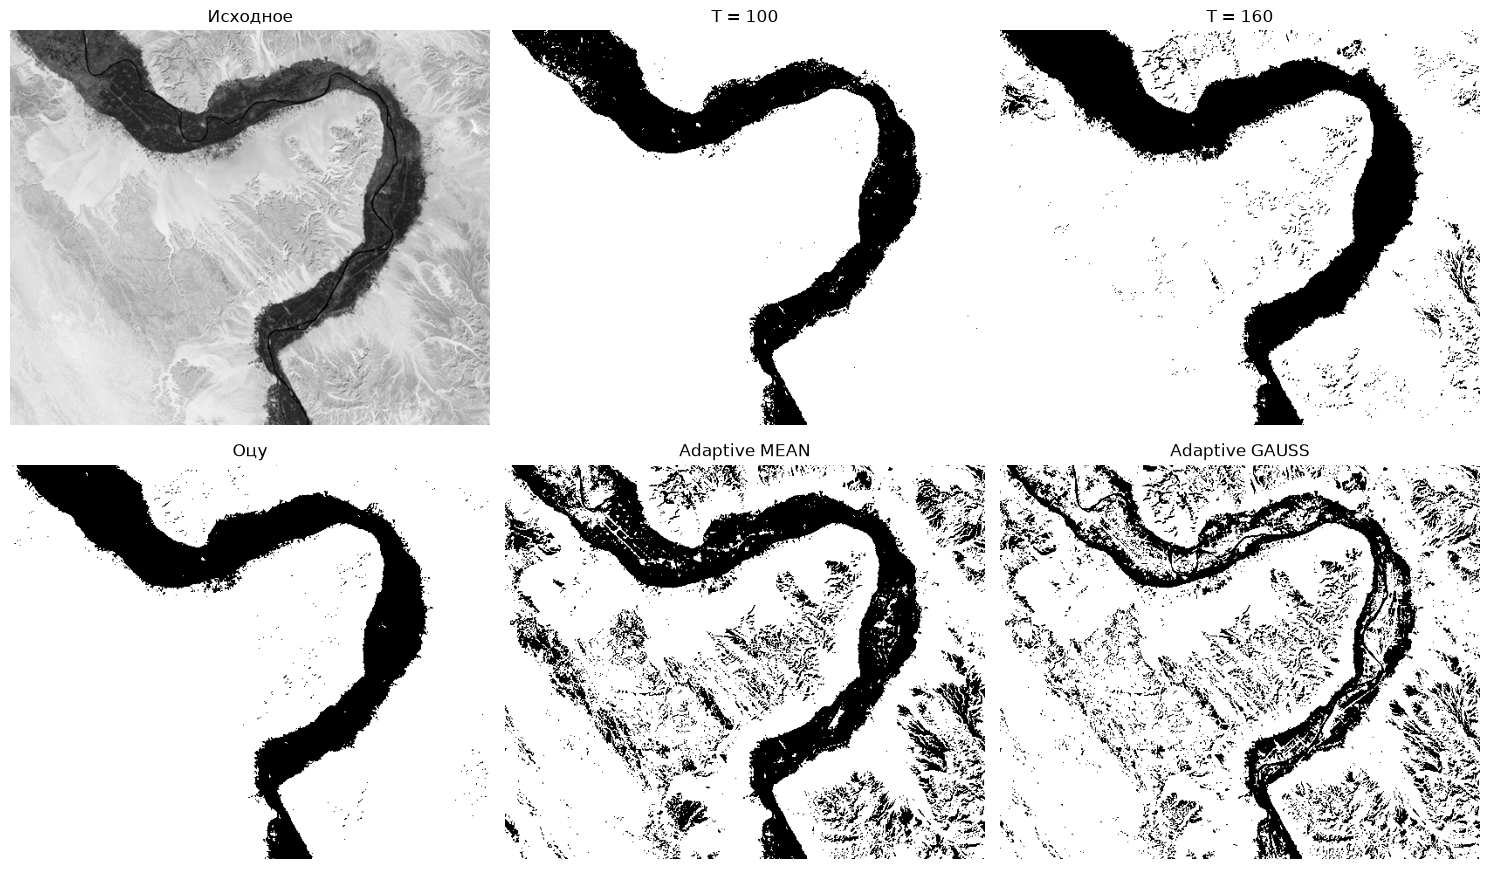

In [50]:
views = [
    ("Исходное",       gray_main,                        "gray"),
    ("T = 100",        fixed_binarize(gray_main, 100),   "gray"),
    ("T = 160",        fixed_binarize(gray_main, 160),   "gray"),
    ("Оцу",            otsu_bin,                         "gray"),
    ("Adaptive MEAN",  adapt_mean,                       "gray"),
    ("Adaptive GAUSS", adapt_gauss,                      "gray"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for a, (title, img, cmap) in zip(axes.ravel(), views):
    a.imshow(img, cmap=cmap)
    a.set_title(title)
    a.axis("off")
plt.tight_layout()
plt.show()

# Обработка линий. Метод Оцу, адаптивная бинаризация

[Otsu, дорога] Порог = 69.0


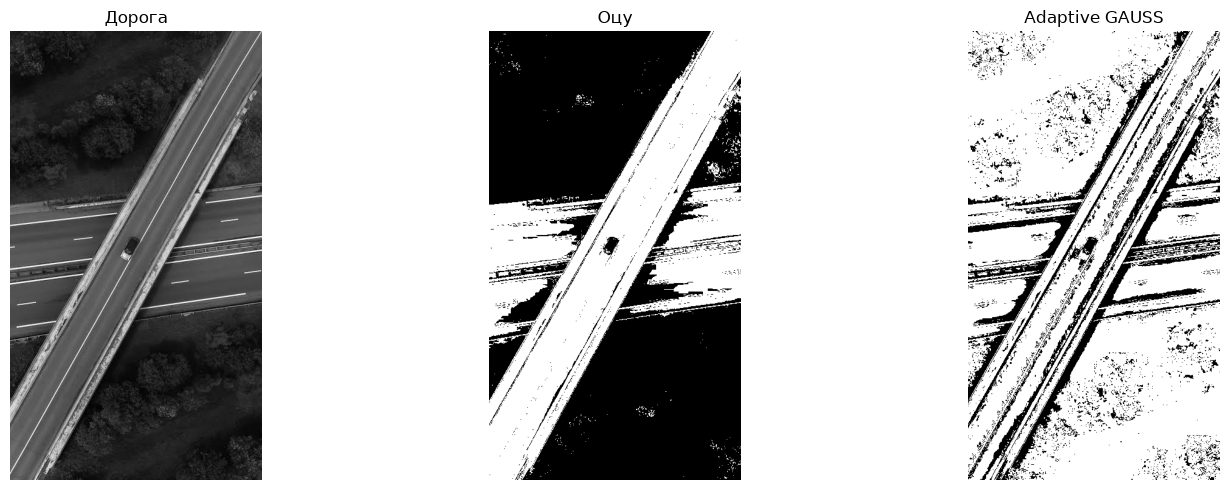

In [51]:
road_otsu_val, road_otsu = cv2.threshold(
    gray_lines, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU
)
road_adapt = cv2.adaptiveThreshold(
    gray_lines, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, block, const
)
print(f"[Otsu, дорога] Порог = {road_otsu_val:.1f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(gray_lines,  cmap="gray"); axes[0].set_title("Дорога")
axes[1].imshow(road_otsu,  cmap="gray"); axes[1].set_title("Оцу")
axes[2].imshow(road_adapt, cmap="gray"); axes[2].set_title("Adaptive GAUSS")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

# Границы Кэнни

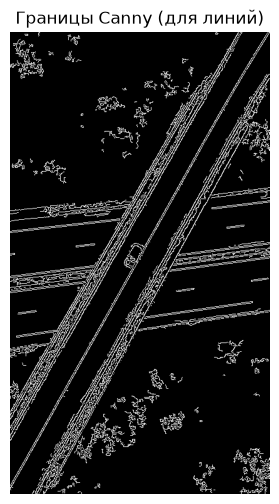

In [52]:
edges_lines = cv2.Canny(gray_lines, 70, 180, apertureSize=3)

plt.figure(figsize=(9, 6))
plt.imshow(edges_lines, cmap="gray")
plt.title("Границы Canny (для линий)")
plt.axis("off")
plt.show()

# Хафф

HoughLines нашёл линий: 75


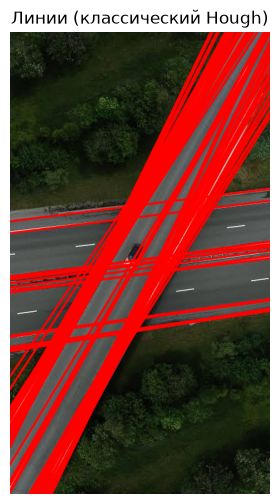

In [53]:
hough_lines = cv2.HoughLines(edges_lines, 1.0, np.pi / 180.0, 150)
print("HoughLines нашёл линий:",
      "нет" if hough_lines is None else len(hough_lines))

canvas = src_lines.copy()
if hough_lines is not None:
    for rho, theta in hough_lines[:, 0]:
        a_, b_ = cos(theta), sin(theta)
        x0, y0 = a_ * rho, b_ * rho
        p1 = (int(x0 + 1000 * (-b_)), int(y0 + 1000 * a_))
        p2 = (int(x0 - 1000 * (-b_)), int(y0 - 1000 * a_))
        cv2.line(canvas, p1, p2, (0, 0, 255), 2, cv2.LINE_AA)

plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title("Линии (классический Hough)")
plt.axis("off")
plt.show()

# Самый протяженный отрезок

Самый длинный отрезок = (46, 737, 413, 74), длина ≈ 757.8 px


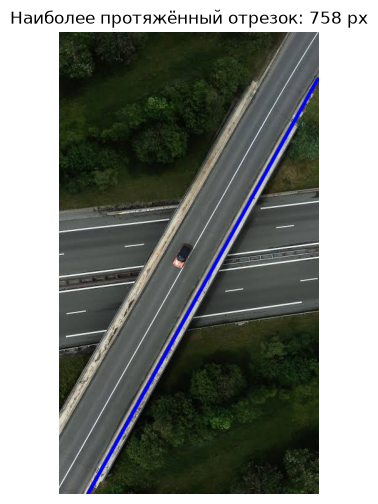

In [54]:
segments = cv2.HoughLinesP(
    edges_lines,
    rho=1.0,
    theta=np.pi / 180.0,
    threshold=90,
    minLineLength=90,
    maxLineGap=15
)

best, best_len = None, 0.0

if segments is not None:
    flat = segments.reshape(-1, 4)
    lengths = np.hypot(flat[:, 2] - flat[:, 0],
                       flat[:, 3] - flat[:, 1])
    idx = int(np.argmax(lengths))
    best = tuple(map(int, flat[idx]))
    best_len = float(lengths[idx])
    print(f"Самый длинный отрезок = {best}, длина ≈ {best_len:.1f} px")
else:
    print("HoughLinesP ничего не нашёл")

marked = src_lines.copy()
if best is not None:
    cv2.line(marked, best[:2], best[2:], (255, 0, 0), 3, cv2.LINE_AA)

plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
plt.title(f"Наиболее протяжённый отрезок: {best_len:.0f} px")
plt.axis("off")
plt.show()

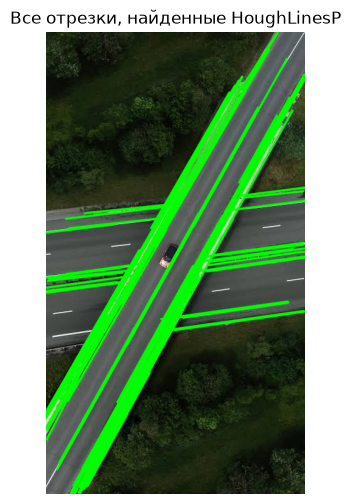

In [55]:
all_segments = src_lines.copy()
if segments is not None:
    for x1, y1, x2, y2 in segments.reshape(-1, 4):
        cv2.line(all_segments, (x1, y1), (x2, y2),
                 (0, 255, 0), 2, cv2.LINE_AA)

plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(all_segments, cv2.COLOR_BGR2RGB))
plt.title("Все отрезки, найденные HoughLinesP")
plt.axis("off")
plt.show()